# Assignment 4: Regularization
Lydia Lee (yzg7bf)

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. Adding a penalty that grows with the size of coeeficients discourages the model from assigning large weights to any single predictor. Without regularization, the model is free to fit noise by using extreme coefficient values. It is trying to find the balance between fitting the data well, but not overfitting.
2. The penalty parameter, alpha, controls where you are on the bias-variance spectrum. A alpha=0, you get ordinary OLS (low bias and high variance). As alpha increases, the coefficients decrease to 0, reducing variance at the cost of introducing bias. Cross-validating over a grid of alpha values lets you find the perfect value that minimizes out-of-sample error.
3. Both add a penalty to MSE, but they differ in its form because Ridge penalizes the squared coefficient. It shrinks all coefficients continuously toward 0 but rarely sets any to 0. Every predictor stays in the model. LASSO penalizes the absolute value (L1 norm). Solutions tend to land exactly on 0 for many coefficients. LASSO performs automatic variable selection, which leads to sparse soltuons.
4. You standardize each feature to have mean 0 and standard deviation 1. The reason is that the penalty applies the same alpha uniformity to all coefficients, so if predictors are on different scales, coefficients measured in small units gets penalized more harshly than they deserve. Standardizing puts all predictors on the same playing field so the penalty is fair for all features.
5. Normally, k-fold cross validation is used to select alpha. You fit the model on a grid of alpha values, evaluate held-out MSE for each, and choose the alpha that minimizes average validation error. Sometime, the "one standard error rule" is used because simpler models are preferred when performance is similar.
6. No because the penalty term is a regularizer added to the training objective to control model complexity. When evaluating held-out performance, you compute plain MSE on the validation fold, without the penalty. Including it would mistake the regularization mechanism with the performance metric and give an incorrect image of how well the model actually predicts the data.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
! git clone https://github.com/lydialeelee/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


             feature           coef
0        Mileage_Run  458071.119627
1                Age -136698.072100
2      Mileage_Run^2  -91643.120024
3    Mileage_Run Age -898405.751356
4              Age^2  113603.822348
5      Mileage_Run^3  -65144.896599
6  Mileage_Run^2 Age  229021.676556
7  Mileage_Run Age^2  368955.713359
8              Age^3  -84038.066146
Optimal alpha: 784.7600


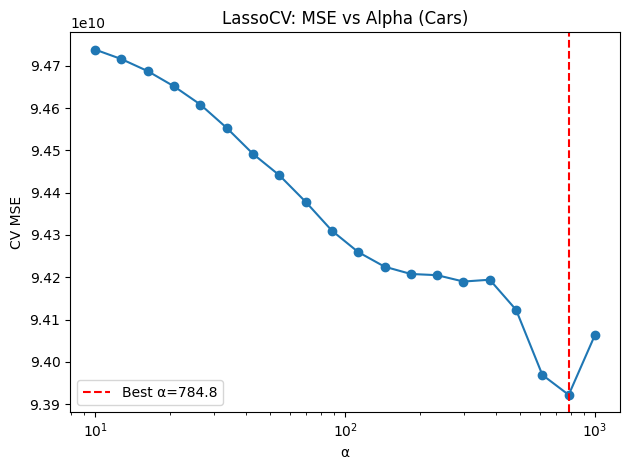

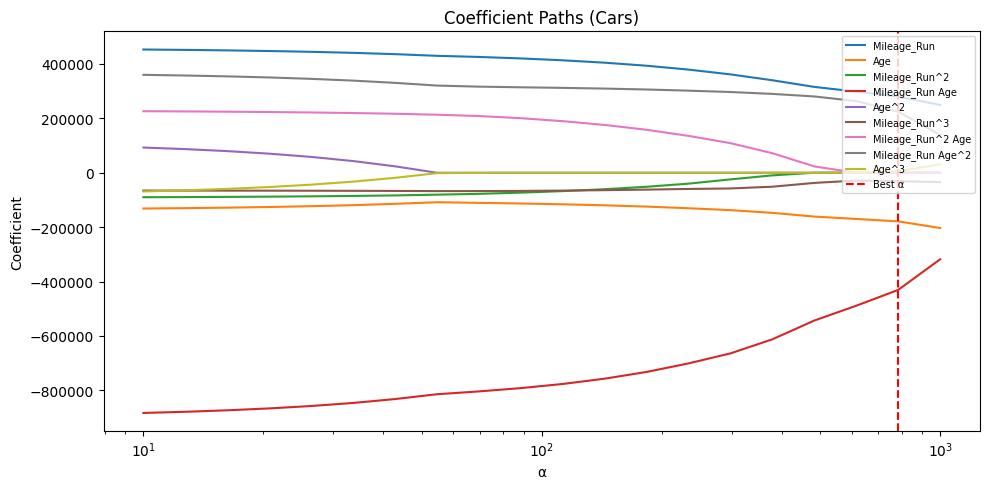

Selected features:
             feature     lasso_coef
0        Mileage_Run  279901.144475
1                Age -178627.649418
3    Mileage_Run Age -430522.371167
5      Mileage_Run^3  -30772.352392
7  Mileage_Run Age^2  224381.027339
8              Age^3    5666.626835
Proportion zeroed out: 33.33%
             feature            OLS          LASSO
0        Mileage_Run  458071.119627  279901.144475
1                Age -136698.072100 -178627.649418
2      Mileage_Run^2  -91643.120024      -0.000000
3    Mileage_Run Age -898405.751356 -430522.371167
4              Age^2  113603.822348      -0.000000
5      Mileage_Run^3  -65144.896599  -30772.352392
6  Mileage_Run^2 Age  229021.676556       0.000000
7  Mileage_Run Age^2  368955.713359  224381.027339
8              Age^3  -84038.066146    5666.626835


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV

# 1. Load data and engineer features
cars = pd.read_csv("/content/undergrad_ml_assignments/data/cars_hw.csv")
cars['Age'] = np.max(cars['Make_Year']) - cars['Make_Year']
cars.head()

X_raw = cars[["Mileage_Run", "Age"]].values

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

y = cars["Price"].values  # adjust target column name if needed

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

# 2. Linear regression — check sign of Mileage_Run x Age interaction
lr = LinearRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({"feature": feature_names, "coef": lr.coef_})
print(coef_df)
# The sign is negative (−898,405.75). A car that is both old and high-mileage loses value faster than either factor alone.

# 3. LassoCV with 20-fold CV
alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso_cv.fit(X_scaled, y)
print(f"Optimal alpha: {lasso_cv.alpha_:.4f}")

# 4. Plot CV-MSE by alpha
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)
plt.figure()
plt.semilogx(lasso_cv.alphas_, mean_mse, marker="o")
plt.axvline(lasso_cv.alpha_, color="red", linestyle="--", label=f"Best α={lasso_cv.alpha_:.1f}")
plt.xlabel("α"); plt.ylabel("CV MSE"); plt.title("LassoCV: MSE vs Alpha (Cars)")
plt.legend(); plt.tight_layout(); plt.show()

# 5. Coefficient paths by alpha
from sklearn.linear_model import Lasso

coefs = []
for a in alphas:
    m = Lasso(alpha=a, max_iter=10000)
    m.fit(X_scaled, y)
    coefs.append(m.coef_)
coefs = np.array(coefs)

plt.figure(figsize=(10, 5))
for j in range(coefs.shape[1]):
    plt.semilogx(alphas, coefs[:, j], label=feature_names[j])
plt.axvline(lasso_cv.alpha_, color="red", linestyle="--", label="Best α")
plt.xlabel("α"); plt.ylabel("Coefficient"); plt.title("Coefficient Paths (Cars)")
plt.legend(fontsize=7, loc="upper right"); plt.tight_layout(); plt.show()

# 6. Selected features
lasso_coefs = pd.DataFrame({"feature": feature_names, "lasso_coef": lasso_cv.coef_})
selected = lasso_coefs[lasso_coefs["lasso_coef"] != 0]
zeroed_frac = (lasso_coefs["lasso_coef"] == 0).mean()
print(f"Selected features:\n{selected}")
print(f"Proportion zeroed out: {zeroed_frac:.2%}")

# 7. Compare OLS vs LASSO coefficients
comparison = pd.DataFrame({
    "feature": feature_names,
    "OLS": lr.coef_,
    "LASSO": lasso_cv.coef_
})
print(comparison)

2.7
- 0 Shrunk
- 1 Increased in magnitude
- 2 Zeroed
- 3 Shrunk
- 4 Zeroed
- 5 Shrunk
- 6 Zeroed
- 7 Shrunk
- 8 Sign flip

Age increased in magnitude. Age^3 changes sign, but it is essentially negligible in magnitude, so it isn't too meaningful.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

hf = pd.read_csv("/content/undergrad_ml_assignments/data/heart_failure_clinical_records_dataset.csv")
y = hf["DEATH_EVENT"].values

# Continuous features: 3rd-degree polynomial expansion & scaling
cont_cols = ["age", "ejection_fraction", "serum_creatinine"]
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly_cont.fit_transform(hf[cont_cols].values)
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)
cont_names = poly_cont.get_feature_names_out(cont_cols)

# Categorical features: interaction_only polynomial (dummies interacted)
cat_cols = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
poly_cat = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(hf[cat_cols].values)
cat_names = poly_cat.get_feature_names_out(cat_cols)

# Combine
X = np.hstack([X_cont_scaled, X_cat])
feature_names = np.concatenate([cont_names, cat_names])

# 2. OLS
lr = LinearRegression()
lr.fit(X, y)
ols_df = pd.DataFrame({"feature": feature_names, "coef": lr.coef_})
print(ols_df)

# 3. LassoCV
alphas = np.logspace(-5, 5, 30)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=50000)
lasso_cv.fit(X, y)
print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")

# 4. CV-MSE plot
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)
plt.figure()
plt.semilogx(lasso_cv.alphas_, mean_mse, marker="o")
plt.axvline(lasso_cv.alpha_, color="red", linestyle="--", label=f"Best α={lasso_cv.alpha_:.5f}")
plt.xlabel("α"); plt.ylabel("CV MSE"); plt.title("LassoCV: MSE vs Alpha (Heart Failure)")
plt.legend(); plt.tight_layout(); plt.show()

# 5. Coefficient paths
coefs = []
for a in alphas:
    m = Lasso(alpha=a, max_iter=50000)
    m.fit(X, y)
    coefs.append(m.coef_)
coefs = np.array(coefs)

plt.figure(figsize=(12, 5))
for j in range(coefs.shape[1]):
    plt.semilogx(alphas, coefs[:, j])
plt.axvline(lasso_cv.alpha_, color="red", linestyle="--", label="Best α")
plt.xlabel("α"); plt.ylabel("Coefficient"); plt.title("Coefficient Paths (Heart Failure)")
plt.tight_layout(); plt.show()

# 6 & compare
lasso_df = pd.DataFrame({
    "feature": feature_names,
    "OLS": lr.coef_,
    "LASSO": lasso_cv.coef_
})
zeroed_frac = (lasso_cv.coef_ == 0).mean()
print(f"Proportion zeroed out: {zeroed_frac:.2%}")
print(lasso_df[lasso_cv.coef_ != 0])

                                   feature      coef
0                                      age  1.549928
1                        ejection_fraction -2.025371
2                         serum_creatinine -0.739027
3                                    age^2 -3.547991
4                    age ejection_fraction -0.861860
5                     age serum_creatinine  1.680570
6                      ejection_fraction^2  3.317931
7       ejection_fraction serum_creatinine  2.604767
8                       serum_creatinine^2 -2.703084
9                                    age^3  1.889040
10                 age^2 ejection_fraction  1.022027
11                  age^2 serum_creatinine -0.672141
12                 age ejection_fraction^2  0.017577
13  age ejection_fraction serum_creatinine -1.584620
14                  age serum_creatinine^2  1.433246
15                     ejection_fraction^3 -1.253594
16    ejection_fraction^2 serum_creatinine -1.219271
17    ejection_fraction serum_creatinine^2  1.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.06442779727989745, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1750842058183224, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.13616435404473748, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: 

2. ejection_fraction is negative at the linear term, but ejection_fraction^2 is positive. Low ejection fraction is a known risk factor for heart failture death, so one would expect the linear term to be negative, but then the squared term "corrects" the curve back up. This is multicollinearity, which is when the polynomial terms are correlated with each other that OLS assigns unstable, which compensate coefficients that individually look wrong but combine to produce a reasonable curve. serum_creatinine is negative linearity, yet serum_creatinine is also negative. High creatinine indicates kidney failure, which should increase death risk, so a negative linear coefficient is weird. This shows multicollinearity again. Finally, the higher-order interaction signs are under OLS with 33 features and only 299 observations. So, this model is overfitting.


3. Optimal alpha: 0.005736

6. 12/33 features retained, so 63.6% zeroed out. LASSO prunes this high-dimensional model. serum_creatinine^3 is the coefficient that increases in magnitude. serum_creatinine, ejection_fraction^3, ejection_fraction^2 serum_creatinine, anaemia, diabetes, high_blood_pressure all changed signs. the LASSO signs do make more sense because anaemia, diabetes, and high_blood_pressure flip to positive under LASSO. It means that they increase death risk, which make sense. Under OLS, they were negative because of the multicollinearity from the correlated polynomial terms. LASSO zeros out most of the redundant higher-order terms and lets the surviving simpler features carry more interpretable signs. This is the bias-variance trade-off because OLS is unbiased with a lot of variance and LASSO introduces bias and reduces variance.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

![question 4](https://github.com/lydialeelee/undergrad_ml_assignments/blob/main/IMG_6199.png?raw=1)

3. As alpha increases, the denominator grows while the numerator stays fixed so $b_1$ is reduced to 0. The model trades bias for variance reduction.